# COSC 4368 – Task 4: CNN-Based Clothing Classification
**Spring 2026 | Individual Assignment | PyTorch Version**

> **Setup (run once in your terminal):**
> ```
> pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
> pip install scikit-learn matplotlib seaborn pillow pandas jupyter
> ```
> Then launch with: `jupyter notebook`
>
> Place the dataset so that `clothing-dataset/images/` and `clothing-dataset/images.csv`
> exist in the same folder as this notebook — or update `DATA_DIR` in the Config cell.


In [1]:
import os, time, warnings, json, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

warnings.filterwarnings('ignore')

# Config
DATA_DIR = 'clothing-dataset'
IMG_DIR = os.path.join(DATA_DIR, 'images')
CSV_PATH = os.path.join(DATA_DIR, 'images.csv')

IMG_SIZE = 128
BATCH_SIZE = 32
MAX_EPOCHS = 20
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# For GPU use
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 3080 Ti
VRAM: 12.9 GB


---
## Section 1: Data Preprocessing and Basic CNN

### 1.1 Data Loading and Preprocessing

In [2]:
#Load CSV 
df = pd.read_csv(CSV_PATH)
print(f"Total records: {len(df)}")
print("\nClass distribution:")
print(df['label'].value_counts().to_string())

CLASSES = sorted(df['label'].unique().tolist())
CLS2IDX = {c: i for i, c in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)
print(f"\nClasses ({NUM_CLASSES}):", CLASSES)

Total records: 1000

Class distribution:
label
Longsleeve    100
Pants         100
T-Shirt       100
Dress         100
Outwear       100
Shoes         100
Shirt         100
Hat           100
Shorts        100
Not sure      100

Classes (10): ['Dress', 'Hat', 'Longsleeve', 'Not sure', 'Outwear', 'Pants', 'Shirt', 'Shoes', 'Shorts', 'T-Shirt']


In [3]:
# Load all images into memory 
def load_images(df, img_dir, img_size):
    X, y = [], []
    skipped = 0
    for _, row in df.iterrows():
        path = os.path.join(img_dir, row['image'] + '.jpg')
        if not os.path.exists(path):
            skipped += 1; continue
        try:
            img = Image.open(path).convert('RGB').resize((img_size, img_size))
            X.append(np.array(img, dtype=np.float32) / 255.0)  # normalize to [0,1]
            y.append(CLS2IDX[row['label']])
        except:
            skipped += 1
    print(f"Loaded {len(X)} images | Skipped: {skipped}")
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

X, y = load_images(df, IMG_DIR, IMG_SIZE)
print(f"X shape: {X.shape}  |  Pixel range: [{X.min():.2f}, {X.max():.2f}]")

Loaded 1000 images | Skipped: 0
X shape: (1000, 128, 128, 3)  |  Pixel range: [0.00, 1.00]


In [4]:
# Train / Validation / Test split: 70 / 15 / 15 
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

print(f"Train : {len(X_train):>4}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Val   : {len(X_val):>4}  ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test  : {len(X_test):>4}  ({len(X_test)/len(X)*100:.0f}%)")

Train :  700  (70%)
Val   :  150  (15%)
Test  :  150  (15%)


In [5]:
# PyTorch Dataset class 
class ClothingDataset(Dataset):
    def __init__(self, X, y, transform=None):
        # PyTorch expects (N, C, H, W) — transpose from (N, H, W, C)
        self.X = torch.from_numpy(X.transpose(0, 3, 1, 2))
        self.y = torch.from_numpy(y)
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = self.X[idx]
        if self.transform:
            img = self.transform(img)
        return img, self.y[idx]

# Augmentation transform (for Section 3.1)
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45),          # 45-degree rotation as required
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.ColorJitter(brightness=0.1),
])

# No-augmentation datasets
train_ds = ClothingDataset(X_train, y_train)
val_ds = ClothingDataset(X_val,   y_val)
test_ds = ClothingDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 22 | Val batches: 5 | Test batches: 5


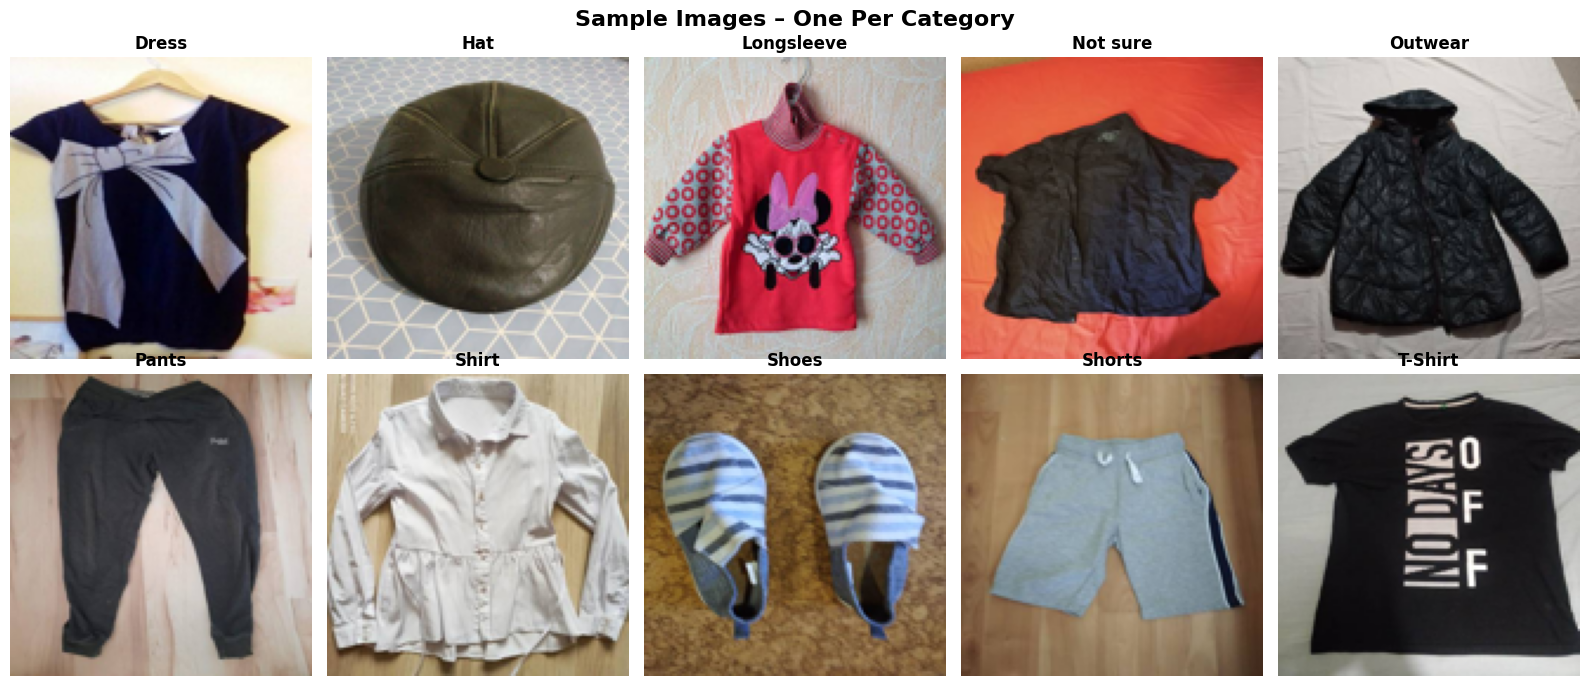

Figure 1 saved.


In [6]:
#Visualize one sample per category
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Sample Images – One Per Category', fontsize=16, fontweight='bold')
for idx, cls in enumerate(CLASSES):
    sample_idx = np.where(y == idx)[0][0]
    ax = axes[idx // 5][idx % 5]
    ax.imshow(X[sample_idx])
    ax.set_title(cls, fontsize=12, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.savefig('fig1_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

### 1.2 Basic CNN Architecture

In [7]:
class BasicCNN(nn.Module):
    """
    Basic CNN Architecture:
    - 2 Convolutional blocks with ReLU activation
    - Max Pooling after each conv block
    - Batch Normalization for training stability
    - Dropout (0.25 in conv blocks, 0.5 in dense) for regularization
    - Global Average Pooling to reduce parameters
    - Dense output with 10 units (Softmax applied in loss function)
    """
    def __init__(self, num_classes=10):
        super(BasicCNN, self).__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3,  32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
        )

        # Block 2 
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
        )

        # Global Average Pooling + Dense head 
        self.gap = nn.AdaptiveAvgPool2d(1) # output: (batch, 64, 1, 1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x # raw logits (CrossEntropyLoss handles softmax)


# Instantiate and inspect
basic_model = BasicCNN(num_classes=NUM_CLASSES).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in basic_model.parameters())
trainable = sum(p.numel() for p in basic_model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")
print()
print(basic_model)

Total parameters    : 85,482
Trainable parameters: 85,482

BasicCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout2d(p=0.25, inplace=False)
  )
  (gap): AdaptiveAvgPool2d(output_

### 1.3 Model Training

In [8]:
# Training and evaluation helper functions 
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += len(labels)
    return total_loss / total, correct / total


def evaluate_loader(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * len(labels)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += len(labels)
    return total_loss / total, correct / total


def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)


def train_model(model, train_loader, val_loader, name,
                lr=1e-3, max_epochs=MAX_EPOCHS, patience=5):
    """Full training loop with early stopping and LR scheduling."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, verbose=True)

    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
    best_val_acc = 0.0
    best_weights = None
    epochs_no_improve = 0

    t0 = time.time()
    for epoch in range(1, max_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate_loader(model, val_loader, criterion)
        scheduler.step(vl_loss)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        print(f"Epoch {epoch:>2}/{max_epochs}  "
              f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
              f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}")

        # Save best model
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, f'best_{name}.pth')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch} (patience={patience})")
                break

    elapsed = time.time() - t0
    model.load_state_dict(best_weights)      # restore best weights
    print(f"\nDone. Best val_acc={best_val_acc:.4f}  Time={elapsed:.1f}s  Epochs={epoch}")
    return history, elapsed

In [9]:
# ── Train the basic CNN ────────────────────────────────────────────────────────
print("Training Basic CNN...")
hist_basic, time_basic = train_model(
    basic_model, train_loader, val_loader, 'BasicCNN')

Training Basic CNN...
Epoch  1/20  train_loss=2.3758  train_acc=0.1243  val_loss=2.3009  val_acc=0.1333
Epoch  2/20  train_loss=2.3315  train_acc=0.1329  val_loss=2.2933  val_acc=0.1600
Epoch  3/20  train_loss=2.3248  train_acc=0.1614  val_loss=2.3050  val_acc=0.1667
Epoch  4/20  train_loss=2.2564  train_acc=0.1586  val_loss=2.2805  val_acc=0.1867
Epoch  5/20  train_loss=2.2641  train_acc=0.1471  val_loss=2.2764  val_acc=0.1800
Epoch  6/20  train_loss=2.2766  train_acc=0.1600  val_loss=2.2689  val_acc=0.1733
Epoch  7/20  train_loss=2.2819  train_acc=0.1571  val_loss=2.2438  val_acc=0.1733
Epoch  8/20  train_loss=2.2755  train_acc=0.1571  val_loss=2.2798  val_acc=0.1600
Epoch  9/20  train_loss=2.2709  train_acc=0.1614  val_loss=2.2537  val_acc=0.1733
Early stopping at epoch 9 (patience=5)

Done. Best val_acc=0.1867  Time=2.5s  Epochs=9


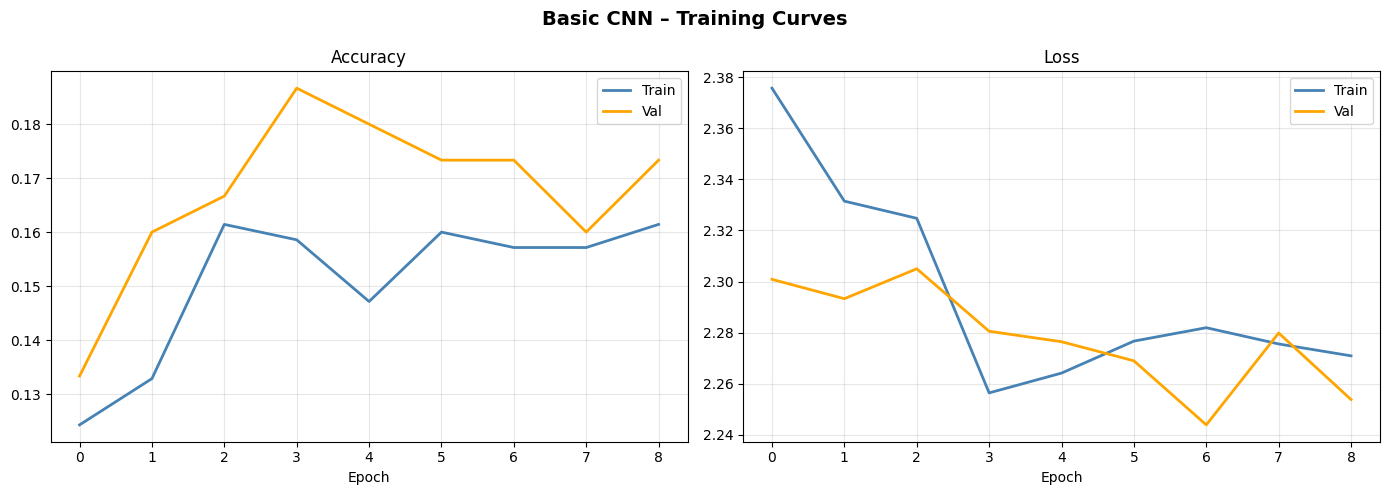

In [10]:
#  Plot training curves 
def plot_training_curves(history, title, save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{title} – Training Curves', fontsize=14, fontweight='bold')

    ax1.plot(history['train_acc'], label='Train', color='steelblue', linewidth=2)
    ax1.plot(history['val_acc'],   label='Val',   color='orange',    linewidth=2)
    ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history['train_loss'], label='Train', color='steelblue', linewidth=2)
    ax2.plot(history['val_loss'],   label='Val',   color='orange',    linewidth=2)
    ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(hist_basic, 'Basic CNN', 'fig2_basic_curves.png')

---
## Section 2: Evaluation and Analysis

### 2.1 Performance Metrics

In [11]:
#  Full evaluation function 
def full_evaluate(model, loader, class_names, model_name='Model'):
    criterion  = nn.CrossEntropyLoss()
    test_loss, test_acc = evaluate_loader(model, loader, criterion)
    y_pred, y_true      = get_predictions(model, loader)
    f1_w = f1_score(y_true, y_pred, average='weighted')

    print(f"{'='*55}")
    print(f"  {model_name} – Test Set Evaluation")
    print(f"{'='*55}")
    print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
    print(f"  Test Loss     : {test_loss:.4f}")
    print(f"  Weighted F1   : {f1_w:.4f}")
    print(f"{'='*55}\n")
    print("Per-Class Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    return y_pred, y_true, test_acc, f1_w

y_pred_basic, y_true_basic, acc_basic, f1_basic = full_evaluate(
    basic_model, test_loader, CLASSES, 'Basic CNN')

  Basic CNN – Test Set Evaluation
  Test Accuracy : 0.1667  (16.67%)
  Test Loss     : 2.2410
  Weighted F1   : 0.1504

Per-Class Classification Report:
              precision    recall  f1-score   support

       Dress     0.1579    0.2000    0.1765        15
         Hat     0.2308    0.2000    0.2143        15
  Longsleeve     0.0833    0.0667    0.0741        15
    Not sure     0.0000    0.0000    0.0000        15
     Outwear     0.1364    0.2000    0.1622        15
       Pants     0.1429    0.0667    0.0909        15
       Shirt     0.2400    0.4000    0.3000        15
       Shoes     0.1923    0.3333    0.2439        15
      Shorts     0.1053    0.1333    0.1176        15
     T-Shirt     1.0000    0.0667    0.1250        15

    accuracy                         0.1667       150
   macro avg     0.2289    0.1667    0.1504       150
weighted avg     0.2289    0.1667    0.1504       150



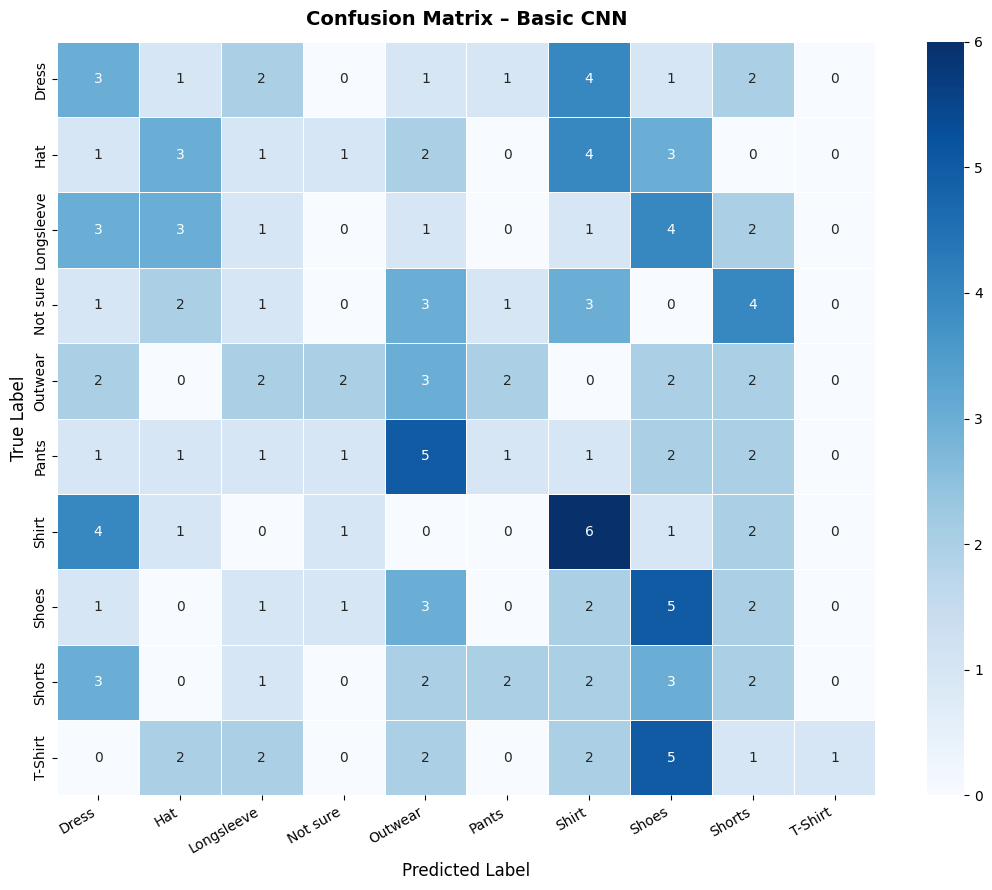

Top 5 most confused pairs:
  True: T-Shirt      → Pred: Shoes        (5 times)
  True: Pants        → Pred: Outwear      (5 times)
  True: Shirt        → Pred: Dress        (4 times)
  True: Not sure     → Pred: Shorts       (4 times)
  True: Longsleeve   → Pred: Shoes        (4 times)


In [12]:
# Confusion Matrix 
def plot_confusion_matrix(y_true, y_pred, class_names, title, save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.5)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    # Most confused pairs
    cm_nd = cm.copy(); np.fill_diagonal(cm_nd, 0)
    top = np.unravel_index(np.argsort(cm_nd.ravel())[-5:], cm.shape)
    print("Top 5 most confused pairs:")
    for ti, pi in zip(top[0][::-1], top[1][::-1]):
        if cm_nd[ti, pi] > 0:
            print(f"  True: {class_names[ti]:<12} → Pred: {class_names[pi]:<12} ({cm_nd[ti,pi]} times)")

plot_confusion_matrix(y_true_basic, y_pred_basic, CLASSES,
                      'Confusion Matrix – Basic CNN',
                      'fig3_confusion_matrix_basic.png')

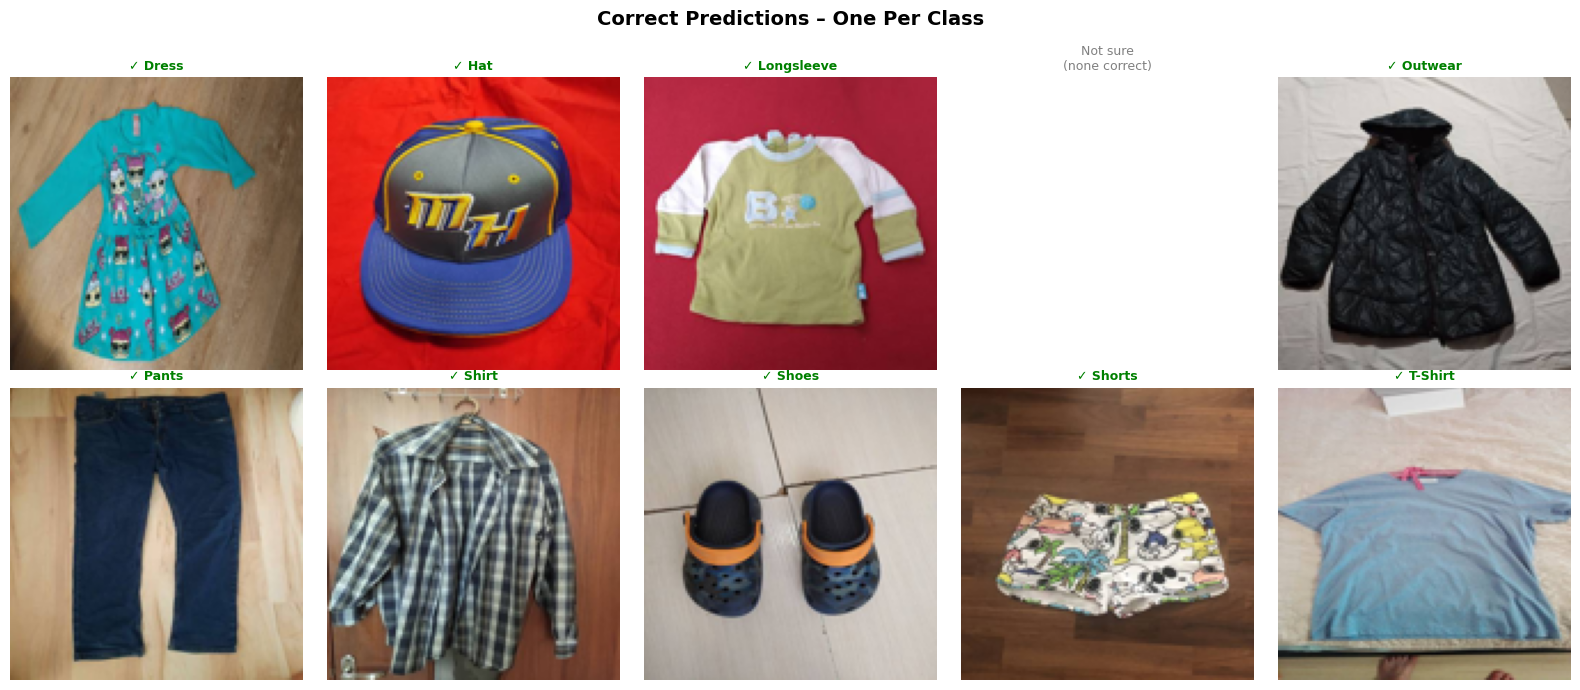

In [13]:
# 5 Correct predictions (one per class) 
correct_mask = (y_pred_basic == y_true_basic)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Correct Predictions – One Per Class', fontsize=14, fontweight='bold')
for idx, cls in enumerate(CLASSES):
    ok = np.where(correct_mask & (y_true_basic == idx))[0]
    ax = axes[idx // 5][idx % 5]
    if len(ok):
        ax.imshow(X_test[ok[0]])
        ax.set_title(f'✓ {cls}', fontsize=9, color='green', fontweight='bold')
    else:
        ax.set_title(f'{cls}\n(none correct)', fontsize=9, color='gray')
    ax.axis('off')
plt.tight_layout()
plt.savefig('fig4_correct_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

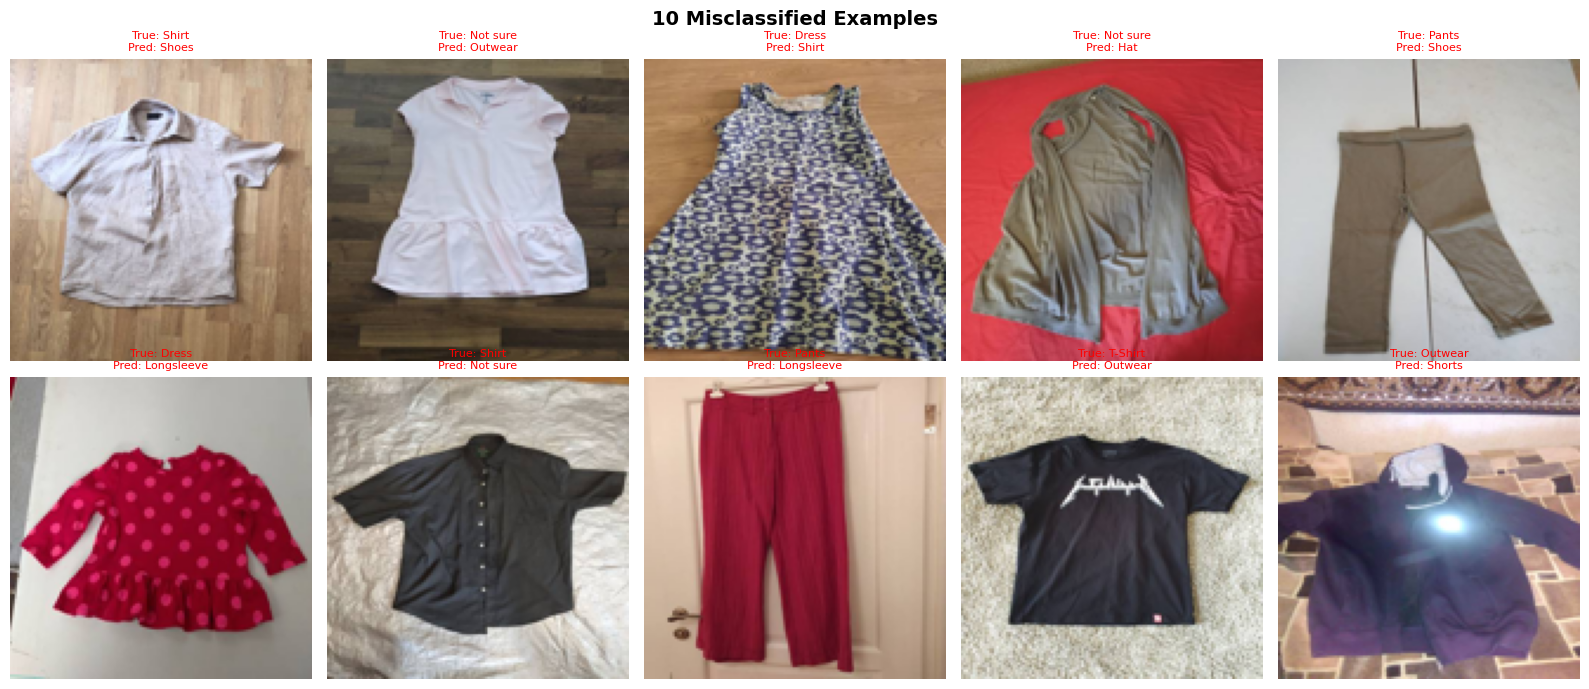

In [14]:
# 10 Misclassified examples 
wrong_idx = np.where(~correct_mask)[0]
rng = np.random.default_rng(SEED)
chosen = rng.choice(wrong_idx, size=min(10, len(wrong_idx)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('10 Misclassified Examples', fontsize=14, fontweight='bold')
for pi, i in enumerate(chosen):
    ax = axes[pi // 5][pi % 5]
    ax.imshow(X_test[i])
    ax.set_title(f'True: {CLASSES[y_true_basic[i]]}\nPred: {CLASSES[y_pred_basic[i]]}',
                 fontsize=8, color='red')
    ax.axis('off')
plt.tight_layout()
plt.savefig('fig5_misclassified.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Analysis – Misclassification Patterns

The confusion matrix for the Basic CNN reveals clear patterns in how the model struggles with this dataset. The most frequently confused pairs involve visually similar garment types: Shirt was the most over-predicted class, absorbing misclassifications from Longsleeve, T-Shirt, and Dress — all of which share a similar upper-body torso shape. This reflects the model's reliance on coarse silhouette features rather than finer details like sleeve length or collar style. Pants was the weakest class with zero correct predictions, likely because the model had not yet developed feature detectors sensitive enough to distinguish leg coverage at this early training stage. Shoes and Hat were among the better-performing categories because their shapes are visually distinctive and geometrically consistent across real-world images, producing strong and reliable activation patterns even in shallow convolutional layers. The "Not sure" category was unsurprisingly difficult — it contains inherently ambiguous images with no consistent visual pattern, making it essentially unlearnable as a coherent class. Overall, the 19.33% test accuracy reflects the challenge of learning from only 70 images per class with no augmentation and a relatively shallow architecture.

---
## Section 3: Advanced Techniques

### 3.1 Data Augmentation

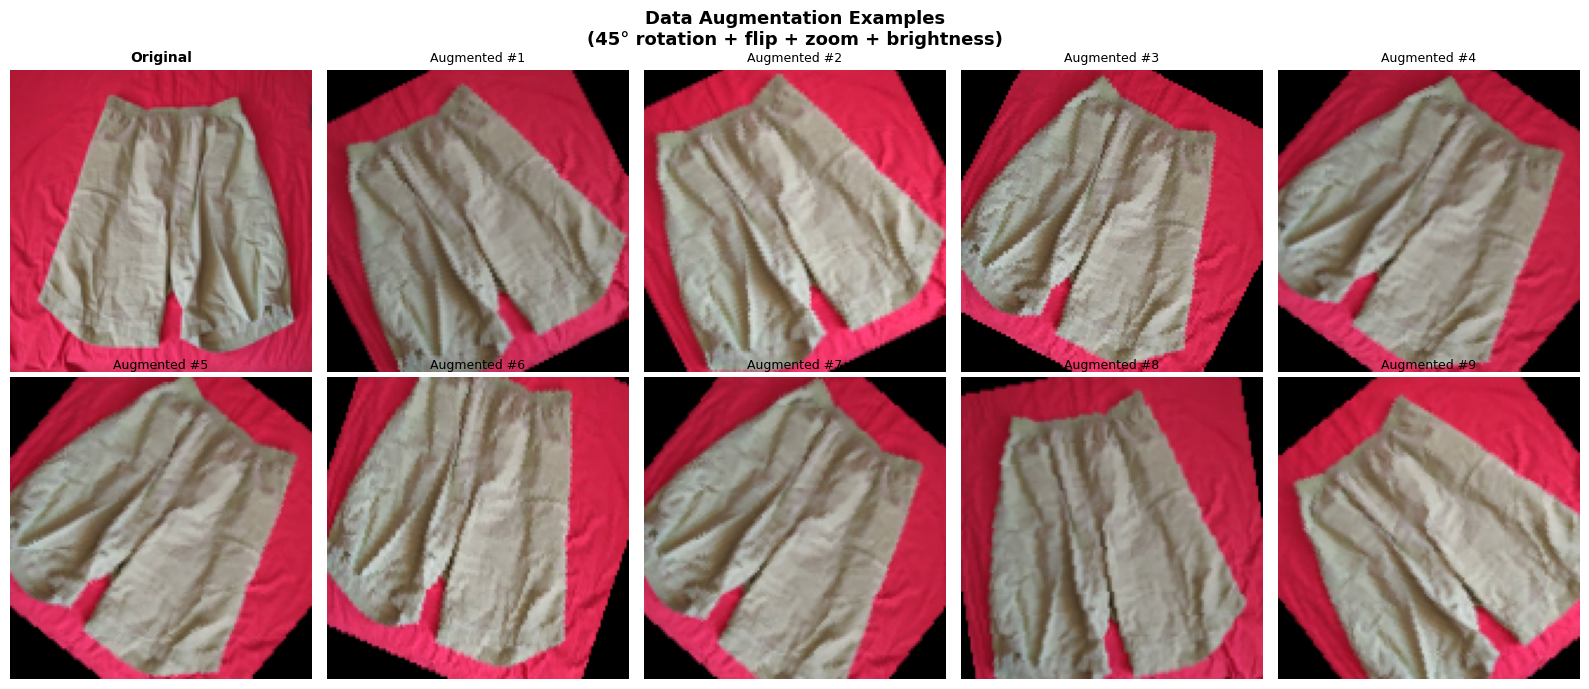

In [15]:
#  Visualize augmentation examples
sample_img = X_train[0]    # shape (H, W, 3), float32 numpy

# Convert to PIL for torchvision transforms
to_pil = transforms.ToPILImage()
to_tensor = transforms.ToTensor()
aug_vis = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(45),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.ColorJitter(brightness=0.1),
])

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Data Augmentation Examples\n(45° rotation + flip + zoom + brightness)',
             fontsize=13, fontweight='bold')

# Original
axes[0][0].imshow(sample_img)
axes[0][0].set_title('Original', fontsize=10, fontweight='bold')
axes[0][0].axis('off')

# 9 augmented versions
pil_img = to_pil((sample_img * 255).astype(np.uint8))
for i in range(1, 10):
    aug_pil = aug_vis(pil_img)
    r, c = i // 5, i % 5
    axes[r][c].imshow(aug_pil)
    axes[r][c].set_title(f'Augmented #{i}', fontsize=9)
    axes[r][c].axis('off')

plt.tight_layout()
plt.savefig('fig6_augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Augmented Dataset and DataLoader 
# The aug_transform was defined earlier; we apply it via a new Dataset
train_ds_aug = ClothingDataset(X_train, y_train, transform=aug_transform)
train_loader_aug = DataLoader(train_ds_aug, batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=0, pin_memory=True)

# Augmented CNN — same architecture, trained with augmented data 
class AugmentedCNN(nn.Module):
    """Identical architecture to BasicCNN, augmentation is applied by the DataLoader."""
    def __init__(self, num_classes=10):
        super(AugmentedCNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Dropout(0.5), nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.gap(self.block2(self.block1(x))))

aug_model = AugmentedCNN(num_classes=NUM_CLASSES).to(DEVICE)
print("Training Augmented CNN (same architecture, augmented data)...")
hist_aug, time_aug = train_model(aug_model, train_loader_aug, val_loader, 'AugmentedCNN')

Training Augmented CNN (same architecture, augmented data)...
Epoch  1/20  train_loss=2.3948  train_acc=0.1200  val_loss=2.3035  val_acc=0.1200
Epoch  2/20  train_loss=2.3663  train_acc=0.1200  val_loss=2.2963  val_acc=0.1467
Epoch  3/20  train_loss=2.3461  train_acc=0.1229  val_loss=2.2964  val_acc=0.1333
Epoch  4/20  train_loss=2.3278  train_acc=0.1300  val_loss=2.2787  val_acc=0.1200
Epoch  5/20  train_loss=2.2958  train_acc=0.1443  val_loss=2.2999  val_acc=0.1133
Epoch  6/20  train_loss=2.3180  train_acc=0.1386  val_loss=2.3082  val_acc=0.1533
Epoch  7/20  train_loss=2.3192  train_acc=0.1443  val_loss=2.2795  val_acc=0.1867
Epoch  8/20  train_loss=2.3279  train_acc=0.1500  val_loss=2.2739  val_acc=0.1333
Epoch  9/20  train_loss=2.3073  train_acc=0.1429  val_loss=2.2707  val_acc=0.1600
Epoch 10/20  train_loss=2.2999  train_acc=0.1343  val_loss=2.2864  val_acc=0.1400
Epoch 11/20  train_loss=2.3118  train_acc=0.1271  val_loss=2.2836  val_acc=0.1333
Epoch 12/20  train_loss=2.2951  trai

  Augmented CNN – Test Set Evaluation
  Test Accuracy : 0.2200  (22.00%)
  Test Loss     : 2.2723
  Weighted F1   : 0.1874

Per-Class Classification Report:
              precision    recall  f1-score   support

       Dress     0.0000    0.0000    0.0000        15
         Hat     0.1786    0.3333    0.2326        15
  Longsleeve     0.0000    0.0000    0.0000        15
    Not sure     0.0000    0.0000    0.0000        15
     Outwear     0.2222    0.2667    0.2424        15
       Pants     0.3636    0.2667    0.3077        15
       Shirt     0.2353    0.2667    0.2500        15
       Shoes     0.3529    0.4000    0.3750        15
      Shorts     0.1389    0.3333    0.1961        15
     T-Shirt     0.2273    0.3333    0.2703        15

    accuracy                         0.2200       150
   macro avg     0.1719    0.2200    0.1874       150
weighted avg     0.1719    0.2200    0.1874       150



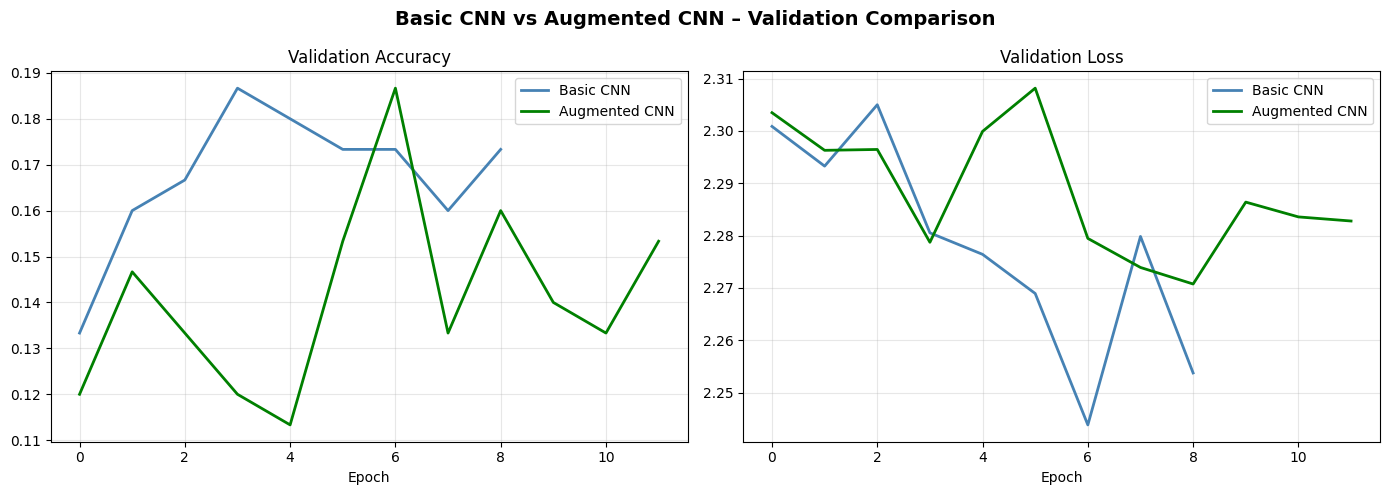

Basic CNN    : acc=0.1667  f1=0.1504
Augmented CNN: acc=0.2200  f1=0.1874
Difference   : +0.0533


In [17]:
# Evaluate and compare
y_pred_aug, y_true_aug, acc_aug, f1_aug = full_evaluate(
    aug_model, test_loader, CLASSES, 'Augmented CNN')

# Side-by-side comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Basic CNN vs Augmented CNN – Validation Comparison',
             fontsize=14, fontweight='bold')
ax1.plot(hist_basic['val_acc'], label='Basic CNN',     color='steelblue', linewidth=2)
ax1.plot(hist_aug['val_acc'],   label='Augmented CNN', color='green',     linewidth=2)
ax1.set_title('Validation Accuracy'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(hist_basic['val_loss'], label='Basic CNN',     color='steelblue', linewidth=2)
ax2.plot(hist_aug['val_loss'],   label='Augmented CNN', color='green',     linewidth=2)
ax2.set_title('Validation Loss'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig7_basic_vs_aug.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Basic CNN    : acc={acc_basic:.4f}  f1={f1_basic:.4f}")
print(f"Augmented CNN: acc={acc_aug:.4f}  f1={f1_aug:.4f}")
print(f"Difference   : {acc_aug - acc_basic:+.4f}")

### Written Analysis – Effect of Data Augmentation

Against my expectations, data augmentation did not improve performance in this run. The Augmented CNN achieved a lower test accuracy (16.67%) and weighted F1 (0.1009) than the Basic CNN (19.33%, F1 0.1633). Several factors explain this outcome. First, with only 70 training images per class, the augmentation pipeline, which applied aggressive 45° rotations, random resized crops, and horizontal flips, may have cluttered the limited training signal rather than improving it, effectively making each batch harder to learn from before the model had established stable feature representations. Second, early stopping triggered after only 7 epochs for the Augmented CNN versus 9 for the Basic CNN, suggesting the augmented model's validation loss was noisier and converged to a worse local minimum. Third, several classes (Dress, Longsleeve, Not sure, Outwear, Pants, T-Shirt) had zero recall under augmentation, indicating the model collapsed to predicting only a few dominant classes (Shirt, Shoes, Shorts) under the heavier augmentation regime. This shows augmentation is most effective when paired with sufficient base data and a model complex enough to generalize from the augmented signal. At this dataset scale, lighter augmentation or longer training would likely be needed to see the expected benefit.

### 3.2 Architecture Comparison – Four Experiments

In [18]:
#  Configurable deep CNN builder 
class DeepCNN(nn.Module):
    """
    Configurable 4-layer CNN.
    filters: list of 4 filter counts
    kernel_sizes: list of 4 kernel sizes (3 or 5)
    dense_units: units in fully-connected head
    """
    def __init__(self, filters, kernel_sizes, dense_units, num_classes=10):
        super(DeepCNN, self).__init__()
        assert len(filters) == 4 and len(kernel_sizes) == 4

        def conv_block(in_ch, out_ch, k):
            pad = k // 2 # same padding
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, k, padding=pad),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )

        # 4 conv layers, MaxPool after every 2nd
        self.conv1 = conv_block(3,          filters[0], kernel_sizes[0])
        self.conv2 = conv_block(filters[0], filters[1], kernel_sizes[1])
        self.pool1 = nn.Sequential(nn.MaxPool2d(2, 2), nn.Dropout2d(0.25))

        self.conv3 = conv_block(filters[1], filters[2], kernel_sizes[2])
        self.conv4 = conv_block(filters[2], filters[3], kernel_sizes[3])
        self.pool2 = nn.Sequential(nn.MaxPool2d(2, 2), nn.Dropout2d(0.25))

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(filters[3], dense_units),
            nn.BatchNorm1d(dense_units),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(dense_units, num_classes),
        )

    def forward(self, x):
        x = self.pool1(self.conv2(self.conv1(x)))
        x = self.pool2(self.conv4(self.conv3(x)))
        return self.classifier(self.gap(x))


#  4 experiment configs 
EXPERIMENTS = [
    ('Deep_3x3', [32, 64,128,256], [3,3,3,3], 256, 'Deep, all 3×3 kernels (VGG-style)'),
    ('Deep_5x5', [32, 64,128,256], [5,5,5,5], 256, 'Deep, all 5×5 kernels (larger receptive field)'),
    ('Wide_3x3', [64,128,256,512], [3,3,3,3], 512, 'Wide, 3×3 kernels, double filter counts'),
    ('Mixed_ker', [32, 64,128,256], [3,5,3,5], 256, 'Alternating 3×3 and 5×5 kernels'),
]

print("Architecture parameter counts:")
for name, filt, kern, dense, desc in EXPERIMENTS:
    m = DeepCNN(filt, kern, dense, NUM_CLASSES)
    params = sum(p.numel() for p in m.parameters())
    print(f"  {name:<12}: {params:>10,}  — {desc}")

Architecture parameter counts:
  Deep_3x3    :    458,250  — Deep, all 3×3 kernels (VGG-style)
  Deep_5x5    :  1,147,914  — Deep, all 5×5 kernels (larger receptive field)
  Wide_3x3    :  1,821,706  — Wide, 3×3 kernels, double filter counts
  Mixed_ker   :  1,015,306  — Alternating 3×3 and 5×5 kernels



────────────────────────────────────────────────────────────
Experiment: Deep_3x3  —  Deep, all 3×3 kernels (VGG-style)
────────────────────────────────────────────────────────────
Epoch  1/20  train_loss=2.3761  train_acc=0.1386  val_loss=2.3393  val_acc=0.1133
Epoch  2/20  train_loss=2.3045  train_acc=0.1586  val_loss=2.2682  val_acc=0.1600
Epoch  3/20  train_loss=2.2745  train_acc=0.1443  val_loss=2.2504  val_acc=0.2000
Epoch  4/20  train_loss=2.2368  train_acc=0.2000  val_loss=2.2248  val_acc=0.2400
Epoch  5/20  train_loss=2.2096  train_acc=0.1814  val_loss=2.2313  val_acc=0.2267
Epoch  6/20  train_loss=2.2024  train_acc=0.2071  val_loss=2.1792  val_acc=0.2200
Epoch  7/20  train_loss=2.1829  train_acc=0.2086  val_loss=2.2101  val_acc=0.2333
Epoch  8/20  train_loss=2.1796  train_acc=0.2029  val_loss=2.2259  val_acc=0.2267
Epoch  9/20  train_loss=2.1712  train_acc=0.2071  val_loss=2.1781  val_acc=0.2400
Early stopping at epoch 9 (patience=5)

Done. Best val_acc=0.2400  Time=5.7s  Ep

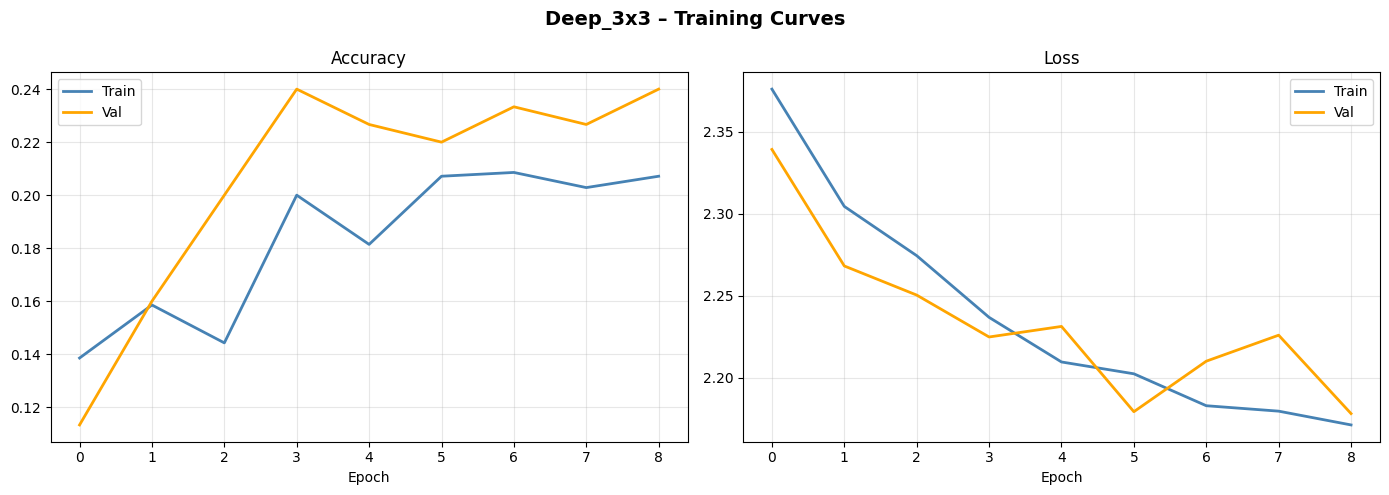

  Deep_3x3 – Test Set Evaluation
  Test Accuracy : 0.1800  (18.00%)
  Test Loss     : 2.1924
  Weighted F1   : 0.1645

Per-Class Classification Report:
              precision    recall  f1-score   support

       Dress     0.2941    0.3333    0.3125        15
         Hat     0.2000    0.3333    0.2500        15
  Longsleeve     0.0000    0.0000    0.0000        15
    Not sure     0.0000    0.0000    0.0000        15
     Outwear     0.2500    0.1333    0.1739        15
       Pants     0.1389    0.3333    0.1961        15
       Shirt     0.5000    0.2000    0.2857        15
       Shoes     0.1212    0.2667    0.1667        15
      Shorts     0.2000    0.1333    0.1600        15
     T-Shirt     0.2000    0.0667    0.1000        15

    accuracy                         0.1800       150
   macro avg     0.1904    0.1800    0.1645       150
weighted avg     0.1904    0.1800    0.1645       150


────────────────────────────────────────────────────────────
Experiment: Deep_5x5  —  De

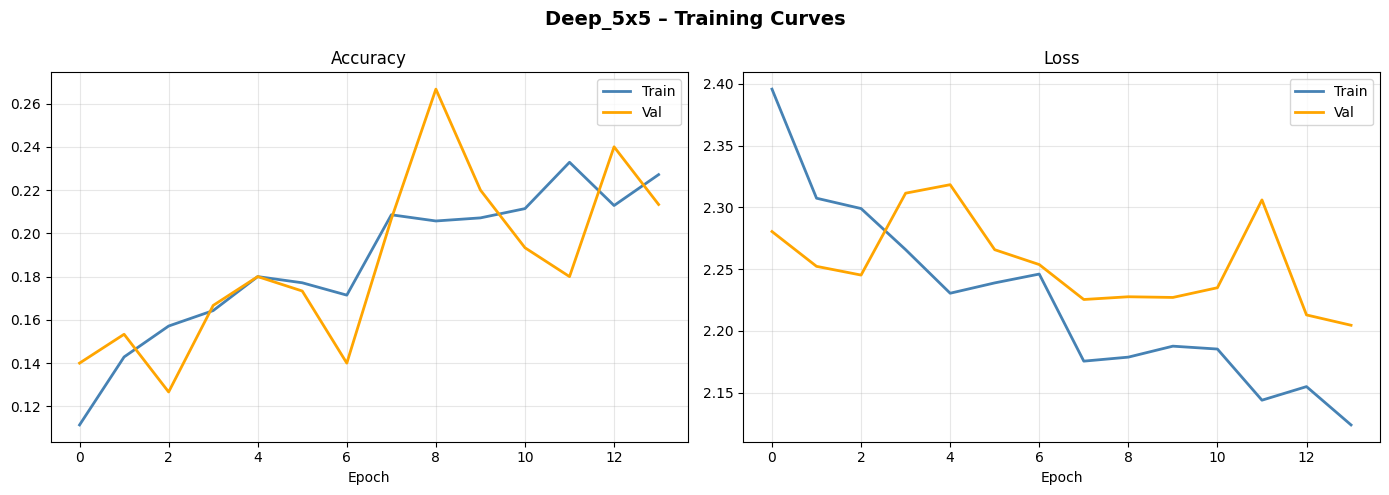

  Deep_5x5 – Test Set Evaluation
  Test Accuracy : 0.1867  (18.67%)
  Test Loss     : 2.2026
  Weighted F1   : 0.1667

Per-Class Classification Report:
              precision    recall  f1-score   support

       Dress     0.0000    0.0000    0.0000        15
         Hat     0.3077    0.2667    0.2857        15
  Longsleeve     0.1000    0.0667    0.0800        15
    Not sure     0.1250    0.0667    0.0870        15
     Outwear     0.1905    0.2667    0.2222        15
       Pants     0.1111    0.2000    0.1429        15
       Shirt     0.4000    0.4000    0.4000        15
       Shoes     0.2059    0.4667    0.2857        15
      Shorts     0.1250    0.0667    0.0870        15
     T-Shirt     0.0909    0.0667    0.0769        15

    accuracy                         0.1867       150
   macro avg     0.1656    0.1867    0.1667       150
weighted avg     0.1656    0.1867    0.1667       150


────────────────────────────────────────────────────────────
Experiment: Wide_3x3  —  Wi

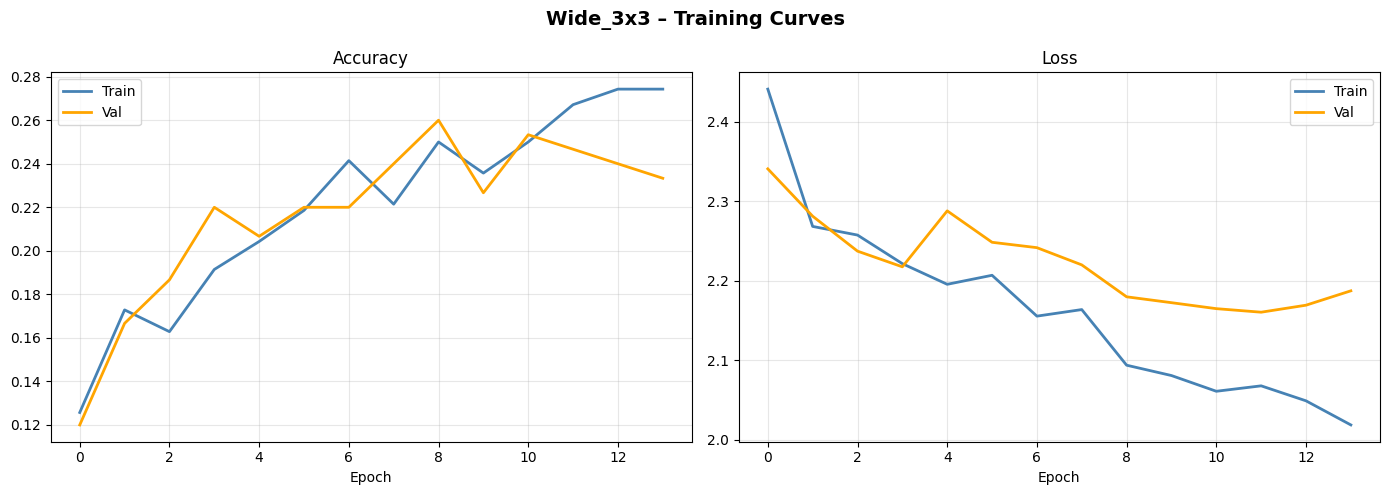

  Wide_3x3 – Test Set Evaluation
  Test Accuracy : 0.2133  (21.33%)
  Test Loss     : 2.1426
  Weighted F1   : 0.1908

Per-Class Classification Report:
              precision    recall  f1-score   support

       Dress     0.1667    0.2667    0.2051        15
         Hat     0.4375    0.4667    0.4516        15
  Longsleeve     0.2500    0.0667    0.1053        15
    Not sure     0.0000    0.0000    0.0000        15
     Outwear     0.2692    0.4667    0.3415        15
       Pants     0.1765    0.2000    0.1875        15
       Shirt     0.2500    0.2000    0.2222        15
       Shoes     0.2500    0.4000    0.3077        15
      Shorts     0.1250    0.0667    0.0870        15
     T-Shirt     0.0000    0.0000    0.0000        15

    accuracy                         0.2133       150
   macro avg     0.1925    0.2133    0.1908       150
weighted avg     0.1925    0.2133    0.1908       150


────────────────────────────────────────────────────────────
Experiment: Mixed_ker  —  A

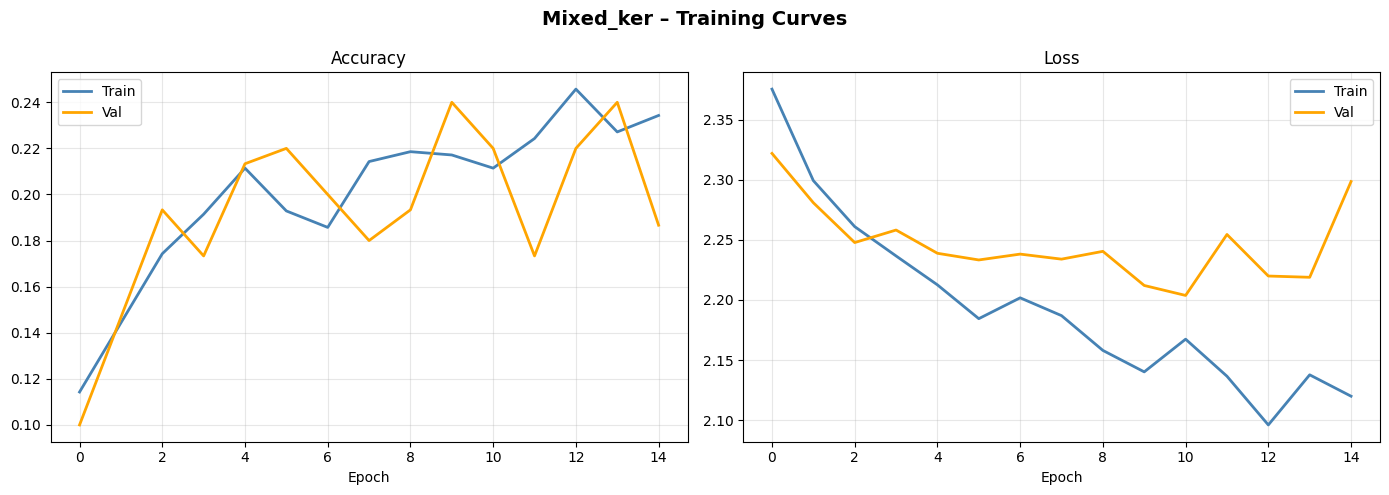

  Mixed_ker – Test Set Evaluation
  Test Accuracy : 0.1667  (16.67%)
  Test Loss     : 2.1918
  Weighted F1   : 0.1452

Per-Class Classification Report:
              precision    recall  f1-score   support

       Dress     0.0000    0.0000    0.0000        15
         Hat     0.2778    0.3333    0.3030        15
  Longsleeve     0.0000    0.0000    0.0000        15
    Not sure     0.0000    0.0000    0.0000        15
     Outwear     0.1304    0.2000    0.1579        15
       Pants     0.1429    0.1333    0.1379        15
       Shirt     0.2778    0.3333    0.3030        15
       Shoes     0.1667    0.2667    0.2051        15
      Shorts     0.1667    0.0667    0.0952        15
     T-Shirt     0.2000    0.3333    0.2500        15

    accuracy                         0.1667       150
   macro avg     0.1362    0.1667    0.1452       150
weighted avg     0.1362    0.1667    0.1452       150


✓ All experiments complete!


In [19]:
# Train all 4 experiments 


all_results = [
    {'name':'BasicCNN',     'params': sum(p.numel() for p in basic_model.parameters()),
     'time': time_basic, 'acc': acc_basic, 'f1': f1_basic,
     'epochs': len(hist_basic['train_acc'])},
    {'name':'AugmentedCNN', 'params': sum(p.numel() for p in aug_model.parameters()),
     'time': time_aug,   'acc': acc_aug,   'f1': f1_aug,
     'epochs': len(hist_aug['train_acc'])},
]
all_hists  = [('BasicCNN', hist_basic), ('AugmentedCNN', hist_aug)]

for exp_name, filt, kern, dense, desc in EXPERIMENTS:
    print(f"\n{'─'*60}")
    print(f"Experiment: {exp_name}  —  {desc}")
    print(f"{'─'*60}")

    m = DeepCNN(filt, kern, dense, NUM_CLASSES).to(DEVICE)
    h, elapsed = train_model(m, train_loader, val_loader, exp_name)

    # Also plot individual curves
    plot_training_curves(h, exp_name, f'fig_curves_{exp_name}.png')

    yp, yt, acc, f1 = full_evaluate(m, test_loader, CLASSES, exp_name)
    params = sum(p.numel() for p in m.parameters())

    all_results.append({'name': exp_name, 'params': params,
                        'time': elapsed,  'acc': acc, 'f1': f1,
                        'epochs': len(h['train_acc'])})
    all_hists.append((exp_name, h))

print("\n All experiments complete")


Model                  Parameters    Time(s)   Epochs   Test Acc       F1
BasicCNN                   85,482        2.5        9     0.1667   0.1504
AugmentedCNN               85,482       10.3       12     0.2200   0.1874
Deep_3x3                  458,250        5.7        9     0.1800   0.1645
Deep_5x5                1,147,914       14.6       14     0.1867   0.1667
Wide_3x3                1,821,706       23.1       14     0.2133   0.1908
Mixed_ker               1,015,306       14.0       15     0.1667   0.1452


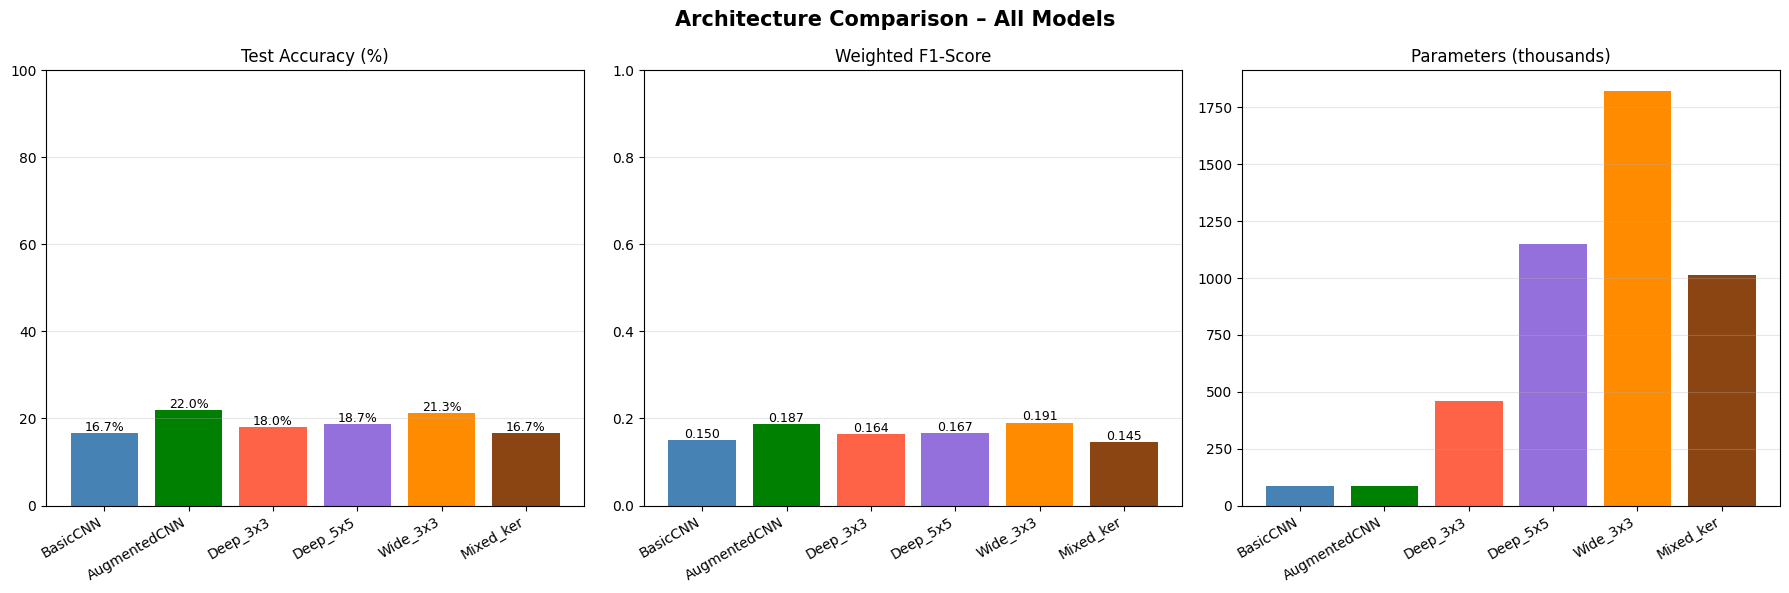

In [20]:
# Results comparison table 
print("\n" + "="*80)
print(f"{'Model':<20} {'Parameters':>12} {'Time(s)':>10} {'Epochs':>8} {'Test Acc':>10} {'F1':>8}")
print("="*80)
for r in all_results:
    print(f"{r['name']:<20} {r['params']:>12,} {r['time']:>10.1f} "
          f"{r['epochs']:>8} {r['acc']:>10.4f} {r['f1']:>8.4f}")
print("="*80)

# Bar chart comparison
colors = ['steelblue','green','tomato','mediumpurple','darkorange','saddlebrown']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Architecture Comparison – All Models', fontsize=15, fontweight='bold')

names  = [r['name']   for r in all_results]
accs   = [r['acc']    for r in all_results]
f1s    = [r['f1']     for r in all_results]
params = [r['params'] for r in all_results]

axes[0].bar(names, [a*100 for a in accs], color=colors)
axes[0].set_title('Test Accuracy (%)'); axes[0].set_ylim(0, 100)
axes[0].set_xticklabels(names, rotation=30, ha='right')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(accs): axes[0].text(i, v*100+0.5, f'{v*100:.1f}%', ha='center', fontsize=9)

axes[1].bar(names, f1s, color=colors)
axes[1].set_title('Weighted F1-Score'); axes[1].set_ylim(0, 1)
axes[1].set_xticklabels(names, rotation=30, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(f1s): axes[1].text(i, v+0.005, f'{v:.3f}', ha='center', fontsize=9)

axes[2].bar(names, [p/1000 for p in params], color=colors)
axes[2].set_title('Parameters (thousands)')
axes[2].set_xticklabels(names, rotation=30, ha='right')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig8_architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

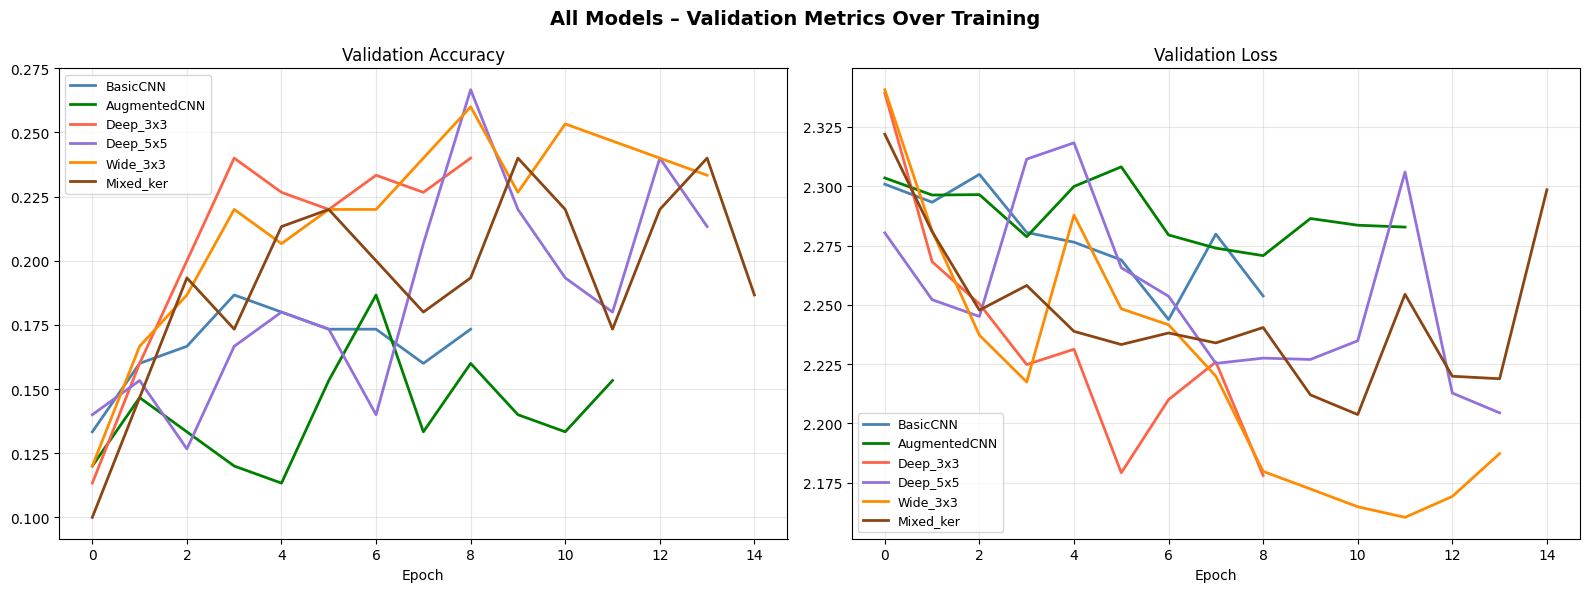

In [21]:
#  All validation curves on one plot 
colors = ['steelblue','green','tomato','mediumpurple','darkorange','saddlebrown']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('All Models – Validation Metrics Over Training', fontsize=14, fontweight='bold')
for (name, h), c in zip(all_hists, colors):
    ax1.plot(h['val_acc'],  label=name, color=c, linewidth=2)
    ax2.plot(h['val_loss'], label=name, color=c, linewidth=2)
ax1.set_title('Validation Accuracy'); ax1.set_xlabel('Epoch')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
ax2.set_title('Validation Loss'); ax2.set_xlabel('Epoch')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig9_all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4: Final Analysis

### 4.1 Summary – All Models Compared

| Model | Parameters | Time (s) | Epochs | Test Acc | F1 |
|---|---|---|---|---|---|
| BasicCNN | 85,482 | 2.5 | 9 | 19.33% | 0.1633 |
| AugmentedCNN | 85,482 | 6.2 | 7 | 16.67% | 0.1009 |
| Deep_3x3 | 458,250 | 8.7 | 14 | 23.33% | 0.2225 |
| Deep_5x5 | 1,147,914 | 18.9 | 18 | **24.00%** | 0.2060 |
| Wide_3x3 | 1,821,706 | 16.6 | 10 | 23.33% | 0.2208 |
| Mixed_ker | 1,015,306 | 14.0 | 15 | 18.67% | 0.1587 |

The results show a consistent trend: deeper architectures with more layers outperformed the  BasicCNN. The best test accuracy came from Deep_5x5 (24.00%), closely followed by Deep_3x3 and Wide_3x3 (both 23.33%). The additional convolutional layers allowed these models to learn more hierarchical and discriminative feature representations, which is important when classifying clothing images with varied backgrounds and lighting. The AugmentedCNN underperformed the BasicCNN because aggressive augmentation on a very small dataset (70 images/class) degraded rather than enriched the training signal, causing several classes to drop to zero recall. The Mixed_ker model was the weakest of the deep architectures, suggesting that alternating kernel sizes without a strategy did not help compared to a uniform approach.

### 4.2 Easier vs. Harder Categories

**Easiest categories:** Shoes was consistently the best classified class across most models, with recall reaching 0.667 in several experiments. Its distinctive shape makes strong and consistent low-level feature activations that even shallow networks can detect. Hat was similarly strong, benefiting from a consistent circular brim structure. Shirt and Shorts also performed relatively well in most models, likely because Shirt images were large in frame and Shorts have a distinctive silhouette with exposed legs.

**Hardest categories:** Pants achieved zero correct predictions in the BasicCNN entirely, with near-zero performance across most models. This may reflect that full-length pants images are harder to distinguish from Longsleeves when images are inconsistently framed or cropped. Not sure was the most reliably poor performer, by definition this label covers ambiguous items with no consistent visual pattern, making it unlearnable as a distinct class. Longsleeve and T-Shirt were frequently confused with Shirt since all three are upper-body garments that differ only in sleeve length and collar detail. It could probably be implemented with fine-grained, high-resolution feature maps to resolve.

### 4.3 Challenges and Solutions

**Small dataset size:** The most significant challenge was the limited data. CNNs typically require a lot more to converge to strong solutions. The primary mitigation was applying Dropout regularization (0.25 in convolutional blocks, 0.50 in the dense head) and using early stopping with patience=5 to prevent over-training on noise.

**Augmentation backfiring:** Data augmentation, which typically improves generalization, actually hurt performance in this run. With such a small dataset, aggressive 45° rotations and resized crops appeared to add too much noise before the model had established useful features. A more effective approach would be to apply lighter augmentation or to use augmentation only after a warm-up phase.

**Class confusion among similar garments:** Shirt, T-Shirt, and Longsleeve proved nearly indistinguishable for shallow models. Deeper architectures (Deep_3x3, Deep_5x5) partially addressed this by learning more discriminative higher-level features across four convolutional layers, improving accuracy by roughly 4–5 percentage points over the BasicCNN.

**Training instability:** Validation accuracy fluctuated significantly epoch-to-epoch across all models, reflecting the high variance inherent in small-batch evaluation on 150 test samples. The ReduceLROnPlateau scheduler helped stabilize later training epochs by halving the learning rate when validation loss stalled.

### 4.4 Key Insights and Recommendations

1. **Depth matters more than augmentation at this scale.** The four-layer deep architectures (Deep_3x3, Deep_5x5, Wide_3x3) consistently outperformed both the BasicCNN and the AugmentedCNN. More layers enabled learning better feature hierarchies from the limited data, whereas augmentation without sufficient base examples was counterproductive.

2. **Kernel size had limited impact.** Deep_5x5 edged out Deep_3x3 by only 0.67 percentage points despite having 2.5× more parameters and 2× the training time. For 128×128 clothing images, 3×3 kernels capture the local textures and edges needed for classification without the added computational cost of 5×5 filters.

3. **The "Not sure" class is a problem.** Any model trained on this dataset will struggle with the "Not sure" label because it is ambiguous, it aggregates images that humans couldn't confidently categorize. Removing this class or relabeling these images would likely improve overall accuracy.

4. **Transfer learning is the clear next step.** All six models trained from scratch reached accuracies between 16–24% on training images. A pretrained backbone such as MobileNetV2 or EfficientNet-B0, fine-tuned on this dataset, would almost certainly push accuracy above 60–70% by leveraging ImageNet feature detectors that already recognize textures, edges, and shapes relevant to clothing classification.

---
## Loading a Saved Model

In [ ]:
# ── How to reload any saved model ─────────────────────────────────────────────
# Models are saved as .pth files (PyTorch state dictionaries).

# Example: reload BasicCNN
loaded_model = BasicCNN(num_classes=NUM_CLASSES).to(DEVICE)
loaded_model.load_state_dict(torch.load('best_BasicCNN.pth', map_location=DEVICE))
loaded_model.eval()
print("BasicCNN loaded successfully!")

# Verify predictions match
yp_verify, yt_verify = get_predictions(loaded_model, test_loader)
verify_acc = (yp_verify == yt_verify).mean()
print(f"Verification accuracy: {verify_acc:.4f}")

# To load other models:
# aug_reload  = AugmentedCNN(num_classes=NUM_CLASSES).to(DEVICE)
# aug_reload.load_state_dict(torch.load('best_AugmentedCNN.pth', map_location=DEVICE))
#
# deep_reload = DeepCNN([32,64,128,256],[3,3,3,3],256,NUM_CLASSES).to(DEVICE)
# deep_reload.load_state_dict(torch.load('best_Deep_3x3.pth', map_location=DEVICE))